<a href="https://colab.research.google.com/github/mishraaashkacs242511-maker/Aashka/blob/main/T095_Aashka_Mishra_AI_Prac_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A) BREADTH-FIRST SEARCH (BFS)
Path: Ginger Andheri MIDC -> Sher E Punjab Colony -> Malpa Dongri -> Juhu Beach
Hops: 3 | Distance: 8.5 km | Nodes explored: 6 | Time: 78.56 us

B) ITERATIVE DEPTH-FIRST SEARCH (DFS)
Path: Ginger Andheri MIDC -> Kanhore Marg -> Mahakali Caves Rd -> Andheri-Ghatkopar Link Rd -> BD Sawant Marg -> Professor NS Phadke Rd -> GK Gokhale Bridge -> Barfiwala Flyover -> Juhu Ln -> Bhaktivedanta Swami Rd -> Cross Rd Number 4 -> NS Rd Number 5 -> Vaikunthlal Mehta Rd -> Juhu Tara Rd -> Juhu Beach
Hops: 14 | Distance: 8.38 km | Nodes explored: 15 | Time: 70.68 us

C) PERFORMANCE & EFFICIENCY COMPARISON
Metric                      BFS                      Iterative DFS            
Path found                  Route A (Service Rd)     Route B (Mahakali Caves Rd)
Hops (edges)                3                        14                       
Total distance (km)         8.5                      8.38                     
Nodes explored              6                        1

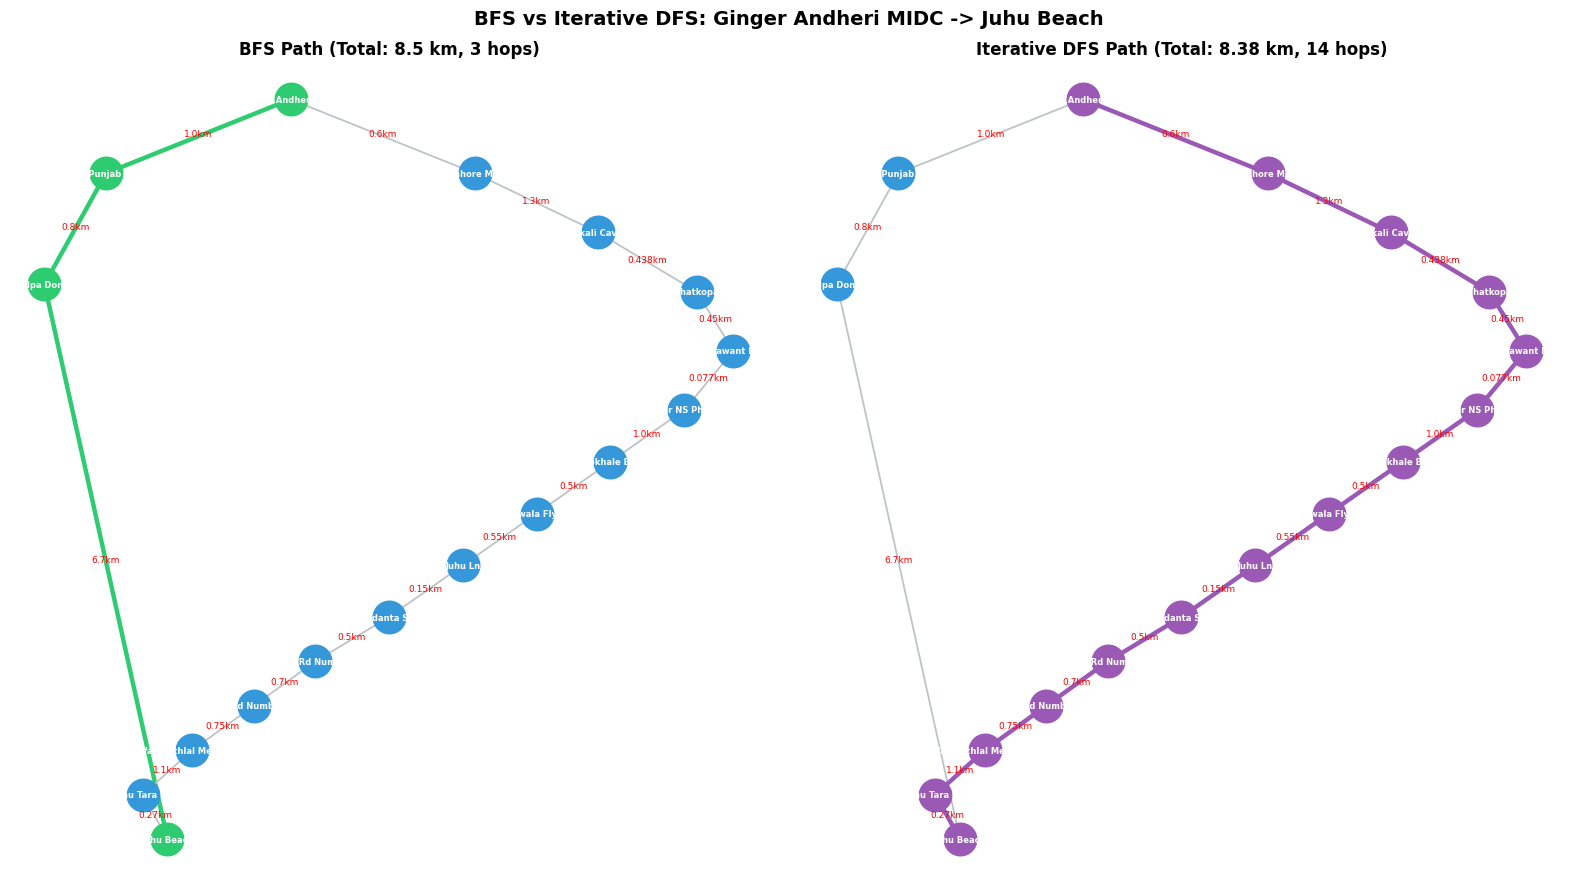

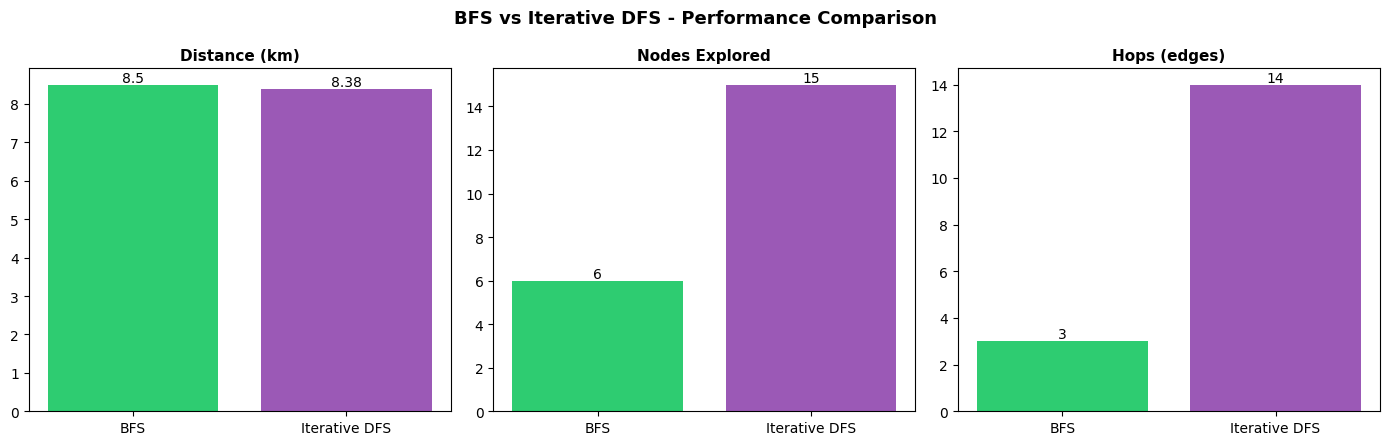

In [3]:
import time
from collections import deque
import matplotlib.pyplot as plt

graph = {
    'Ginger Andheri MIDC':        {'Sher E Punjab Colony': 1.0, 'Kanhore Marg': 0.6},
    'Sher E Punjab Colony':       {'Malpa Dongri': 0.8},
    'Malpa Dongri':               {'Juhu Beach': 6.7},
    'Kanhore Marg':               {'Mahakali Caves Rd': 1.3},
    'Mahakali Caves Rd':          {'Andheri-Ghatkopar Link Rd': 0.438},
    'Andheri-Ghatkopar Link Rd':  {'BD Sawant Marg': 0.45},
    'BD Sawant Marg':             {'Professor NS Phadke Rd': 0.077},
    'Professor NS Phadke Rd':     {'GK Gokhale Bridge': 1.0},
    'GK Gokhale Bridge':          {'Barfiwala Flyover': 0.5},
    'Barfiwala Flyover':          {'Juhu Ln': 0.55},
    'Juhu Ln':                    {'Bhaktivedanta Swami Rd': 0.15},
    'Bhaktivedanta Swami Rd':     {'Cross Rd Number 4': 0.5},
    'Cross Rd Number 4':          {'NS Rd Number 5': 0.7},
    'NS Rd Number 5':             {'Vaikunthlal Mehta Rd': 0.75},
    'Vaikunthlal Mehta Rd':       {'Juhu Tara Rd': 1.1},
    'Juhu Tara Rd':               {'Juhu Beach': 0.27},
    'Juhu Beach':                 {}
}

coords = {
    'Ginger Andheri MIDC':       (2, 10),
    'Sher E Punjab Colony':      (0.5, 9),
    'Malpa Dongri':               (0, 7.5),
    'Kanhore Marg':               (3.5, 9),
    'Mahakali Caves Rd':          (4.5, 8.2),
    'Andheri-Ghatkopar Link Rd':  (5.3, 7.4),
    'BD Sawant Marg':             (5.6, 6.6),
    'Professor NS Phadke Rd':     (5.2, 5.8),
    'GK Gokhale Bridge':          (4.6, 5.1),
    'Barfiwala Flyover':          (4.0, 4.4),
    'Juhu Ln':                    (3.4, 3.7),
    'Bhaktivedanta Swami Rd':     (2.8, 3.0),
    'Cross Rd Number 4':          (2.2, 2.4),
    'NS Rd Number 5':             (1.7, 1.8),
    'Vaikunthlal Mehta Rd':       (1.2, 1.2),
    'Juhu Tara Rd':               (0.8, 0.6),
    'Juhu Beach':                 (1, 0)
}

def path_distance(path):
    """Sum the real road-distance weights along a discovered path."""
    return round(sum(graph[path[i]][path[i + 1]] for i in range(len(path) - 1)), 2)


# A) BREADTH-FIRST SEARCH (BFS)
def bfs_search(graph, start, goal):
    frontier = deque([[start]])   # FIFO queue of paths
    visited = {start}
    nodes_explored = 0

    while frontier:
        path = frontier.popleft()          # dequeue from the FRONT
        node = path[-1]
        nodes_explored += 1

        if node == goal:
            return path, nodes_explored

        for neighbor in graph[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                frontier.append(path + [neighbor])

    return None, nodes_explored

# B) ITERATIVE DEPTH-FIRST SEARCH (DFS)
def dfs_search(graph, start, goal):
    stack = [[start]]
    visited = set()
    nodes_explored = 0

    while stack:
        path = stack.pop()
        node = path[-1]

        if node in visited:
            continue
        visited.add(node)
        nodes_explored += 1

        if node == goal:
            return path, nodes_explored

        for neighbor in graph[node]:
            if neighbor not in visited:
                stack.append(path + [neighbor])

    return None, nodes_explored


start, goal = 'Ginger Andheri MIDC', 'Juhu Beach'

t0 = time.perf_counter()
bfs_path, bfs_nodes = bfs_search(graph, start, goal)
t1 = time.perf_counter()
bfs_time = (t1 - t0) * 1e6

t0 = time.perf_counter()
dfs_path, dfs_nodes = dfs_search(graph, start, goal)
t1 = time.perf_counter()
dfs_time = (t1 - t0) * 1e6

bfs_dist = path_distance(bfs_path)
dfs_dist = path_distance(dfs_path)

print("A) BREADTH-FIRST SEARCH (BFS)")
print(f"Path: {' -> '.join(bfs_path)}")
print(f"Hops: {len(bfs_path) - 1} | Distance: {bfs_dist} km | Nodes explored: {bfs_nodes} | Time: {bfs_time:.2f} us\n")

print("B) ITERATIVE DEPTH-FIRST SEARCH (DFS)")
print(f"Path: {' -> '.join(dfs_path)}")
print(f"Hops: {len(dfs_path) - 1} | Distance: {dfs_dist} km | Nodes explored: {dfs_nodes} | Time: {dfs_time:.2f} us\n")

print("C) PERFORMANCE & EFFICIENCY COMPARISON")
print(f"{'Metric':<28}{'BFS':<25}{'Iterative DFS':<25}")
print(f"{'Path found':<28}{'Route A (Service Rd)':<25}{'Route B (Mahakali Caves Rd)':<25}")
print(f"{'Hops (edges)':<28}{len(bfs_path)-1:<25}{len(dfs_path)-1:<25}")
print(f"{'Total distance (km)':<28}{bfs_dist:<25}{dfs_dist:<25}")
print(f"{'Nodes explored':<28}{bfs_nodes:<25}{dfs_nodes:<25}")
print(f"{'Time taken (microseconds)':<28}{bfs_time:<25.2f}{dfs_time:<25.2f}")
print(f"{'Time complexity':<28}{'O(V + E)':<25}{'O(V + E)':<25}")
print(f"{'Space complexity':<28}{'O(V)  (wide frontier)':<25}{'O(V)  (deep stack)':<25}")
print(f"{'Optimality':<28}{'Optimal in HOPS only':<25}{'Not optimal (order-dep.)':<25}")

fig, axes = plt.subplots(1, 2, figsize=(16, 9))

def draw_route(ax, path, path_color, title):
    for node, neighbors in graph.items():
        x1, y1 = coords[node]
        for neighbor, dist in neighbors.items():
            x2, y2 = coords[neighbor]
            is_path = node in path and neighbor in path and path.index(neighbor) == path.index(node) + 1
            color, width = (path_color, 3.2) if is_path else ('#bdc3c7', 1.3)
            ax.plot([x1, x2], [y1, y2], color=color, linewidth=width, zorder=1)
            ax.text((x1 + x2) / 2, (y1 + y2) / 2, f"{dist}km", color='red', fontsize=6.5, ha='center')

    for node, (x, y) in coords.items():
        color = path_color if node in path else '#3498db'
        ax.scatter(x, y, color=color, s=550, zorder=2)
        ax.text(x, y, node, ha='center', va='center', color='white', fontsize=6, fontweight='bold')

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')

draw_route(axes[0], bfs_path, '#2ecc71', f"BFS Path (Total: {bfs_dist} km, {len(bfs_path)-1} hops)")
draw_route(axes[1], dfs_path, '#9b59b6', f"Iterative DFS Path (Total: {dfs_dist} km, {len(dfs_path)-1} hops)")

plt.suptitle("BFS vs Iterative DFS: Ginger Andheri MIDC -> Juhu Beach", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('BFS_vs_DFS_Andheri_to_JuhuBeach.png', dpi=150)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
metrics = [
    ('Distance (km)', [bfs_dist, dfs_dist]),
    ('Nodes Explored', [bfs_nodes, dfs_nodes]),
    ('Hops (edges)', [len(bfs_path) - 1, len(dfs_path) - 1]),
]
labels = ['BFS', 'Iterative DFS']
colors = ['#2ecc71', '#9b59b6']

for ax, (title, values) in zip(axes, metrics):
    bars = ax.bar(labels, values, color=colors)
    ax.set_title(title, fontsize=11, fontweight='bold')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(val),
                ha='center', va='bottom', fontsize=10)

plt.suptitle("BFS vs Iterative DFS - Performance Comparison", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('BFS_vs_DFS_Comparison_Chart.png', dpi=150)
plt.show()